In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.parser import parse
from scipy import stats
import numpy as np

In [2]:
f = '../data/ClimaLab_2023-05-31_2025-06-20.parquet'
tdb = pd.read_parquet(f,columns=['tdb','solar_altitude'])
dia = tdb[tdb.solar_altitude>=0]
noche = tdb[tdb.solar_altitude<0]
noche

variable,tdb,solar_altitude
date,,
2023-05-31 19:09:00,27.50,-0.085744
2023-05-31 19:10:00,27.53,-0.271267
2023-05-31 19:11:00,27.53,-1.003378
2023-05-31 19:12:00,27.58,-1.219907
2023-05-31 19:13:00,27.60,-1.436298
...,...,...
2025-06-19 23:56:00,18.88,-46.462932
2025-06-19 23:57:00,18.89,-46.520379
2025-06-19 23:58:00,18.87,-46.576532


(np.float64(19734.0), np.float64(19744.0))

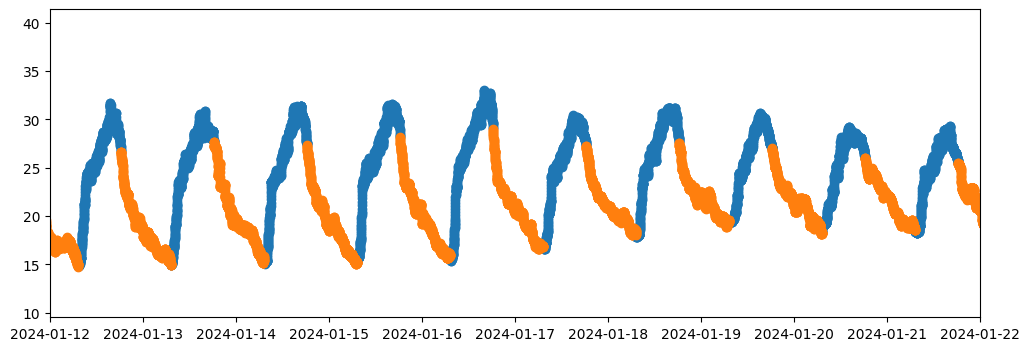

In [5]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse('01-12-2024')
f2 = f1 + pd.Timedelta('10D')

ax.scatter(dia.index,dia.tdb)
ax.scatter(noche.index,noche.tdb)
# ax.plot(noche.tdb)

ax.set_xlim(f1,f2)

In [6]:
print(len(dia),len(noche))

544287 532481


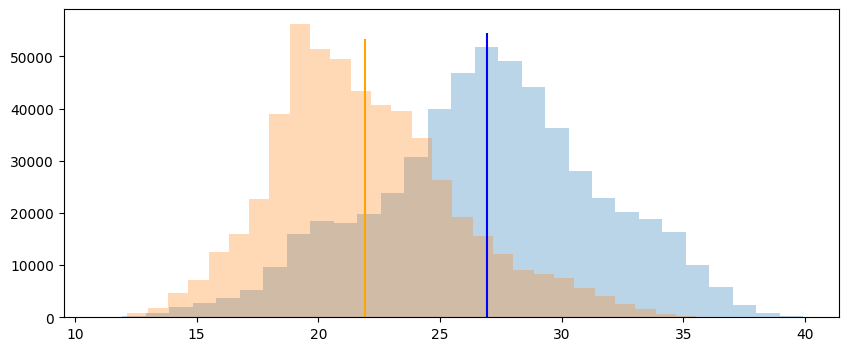

In [7]:
fig, ax = plt.subplots(figsize=(10,4))

ax.hist(dia.tdb, alpha=0.3, bins = 30,);
ax.hist(noche.tdb, alpha=0.3, bins = 30);

ax.vlines(dia.tdb.mean(),ymin=0,ymax=len(dia.tdb)/10,colors='blue')
ax.vlines(noche.tdb.mean(),ymin=0,ymax=len(noche.tdb)/10,colors='orange')


  $$
  t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
  $$

  donde:
  - $\bar{x}$ = media de muestra_noche
  - $\mu_0$ = mu_dia (el valor con el que comparas)
  - $s$ = desviación estándar de la muestra
  - $n$ = tamaño de muestra

  Intuitivamente: "¿cuántos errores estándar separan mi media muestral del promedio del día?"

  ¿Qué significa que sea negativo?

  El signo sólo indica dirección:

  - t_stat < 0 → la media de tu muestra de noche es menor que mu_dia (lo esperable: de noche hace más frío que de día).
  - t_stat > 0 → sería mayor.
  - t_stat ≈ 0 → prácticamente iguales.


  ¿Y el p-valor?

In [8]:
n = 2
muestra_noche = noche['tdb'].sample(n)
mu_dia = dia['tdb'].mean()

# H0: la media de la muestra de noche es igual al promedio del día
t_stat, p_valor = stats.ttest_1samp(muestra_noche, popmean=mu_dia)
t_stat, p_valor

(np.float64(-7.952420765844685), np.float64(0.0796355913243386))

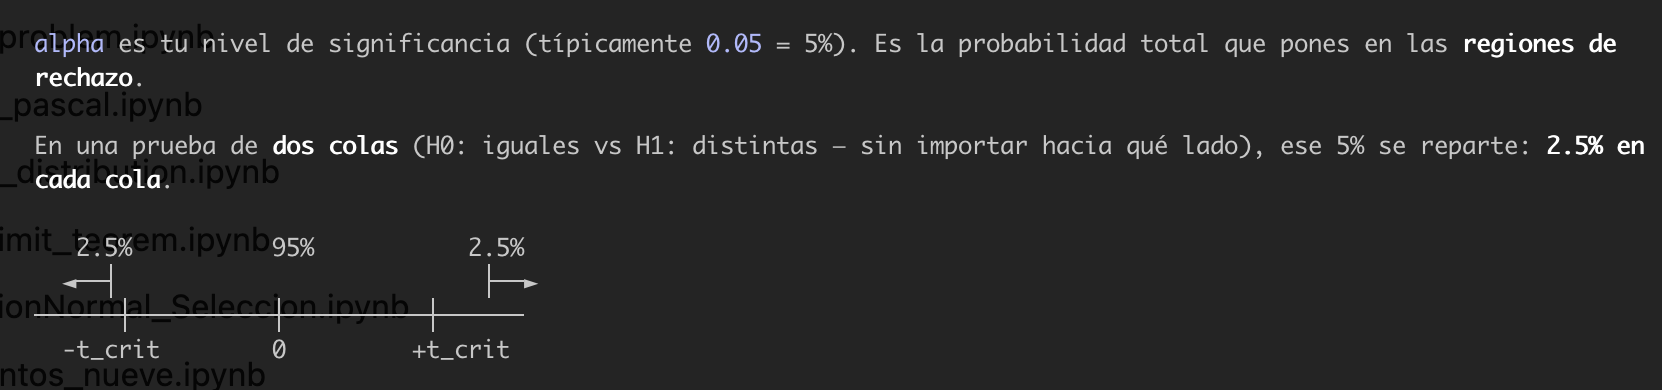

#### `stats.t.ppf(1 - alpha/2, gl)`

Devuelve el **valor crítico** $t_{\text{crit}}$ de la distribución t: el umbral que separa la región de no rechazo de
las colas de rechazo en una prueba de dos colas.

$$
gl = n - 1, \qquad P(T \leq t_{\text{crit}}) = 1 - \tfrac{\alpha}{2}
$$

Deja $\alpha/2$ de probabilidad en cada cola.

**Estadístico observado:**

$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$$

**Decisión:** se rechaza $H_0$ si $|t| > t_{\text{crit}}$.

$t_{\text{crit}}$ está en unidades de **error estándar** ($s/\sqrt{n}$).

In [11]:

n = 2
def evalua(n):
    muestra_noche = noche['tdb'].sample(n)
    mu_dia = dia['tdb'].mean()
    
    # H0: la media de la muestra de noche es igual al promedio del día
    t_stat, p_valor = stats.ttest_1samp(muestra_noche, popmean=mu_dia)
    
    alpha = 0.05
    print(f'promedio día: {mu_dia:.3f}')
    print(f'media muestra noche (n={n}): {muestra_noche.mean():.3f}')
    print(f't = {t_stat:.3f},  p = {p_valor:.4f}')
    print('Rechazamos H0 (son distintas)' if p_valor < alpha else 'No rechazamos H0 (estadísticamente iguales)')
    
    
    gl = n - 1
    t_critico = stats.t.ppf(1 - alpha/2, gl)
    
    
    lim = max(4, abs(t_stat), t_critico) * 1.1
    x = np.linspace(-lim, lim, 600)
    y = stats.t.pdf(x, gl)
    
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(muestra_noche, bins=15, edgecolor='k', alpha=0.7, label=f'muestra noche (n={n})')
    ax1.axvline(mu_dia, color='red', ls='--', lw=2, label=f'μ día = {mu_dia:.2f}')
    ax1.axvline(muestra_noche.mean(), color='green', ls='--', lw=2,
              label=f'media muestra = {muestra_noche.mean():.2f}')
    ax1.set_xlabel('tdb'); ax1.set_ylabel('frecuencia')
    ax1.set_title('Muestra de noche vs. promedio del día')
    ax1.legend()
    
    ax2.plot(x, y, 'b-', lw=2, label=f't(gl={gl})')
    ax2.fill_between(x, y, where=(x <= -t_critico), color='red', alpha=0.3, label='región de rechazo')
    ax2.fill_between(x, y, where=(x >=  t_critico), color='red', alpha=0.3)
    ax2.axvline(t_stat, color='green', lw=2, label=f't obs = {t_stat:.2f}')
    ax2.axvline( t_critico, color='k', ls=':', lw=1)
    ax2.axvline(-t_critico, color='k', ls=':', lw=1, label=f'±t crit = ±{t_critico:.2f}')
    ax2.set_xlabel('t'); ax2.set_ylabel('densidad')
    ax2.set_title(f'Distribución t bajo H0  (p = {p_valor:.4f})')
    ax2.legend()
    
    plt.tight_layout(); plt.show()

promedio día: 26.919
media muestra noche (n=20): 22.203
t = -3.814,  p = 0.0012
Rechazamos H0 (son distintas)


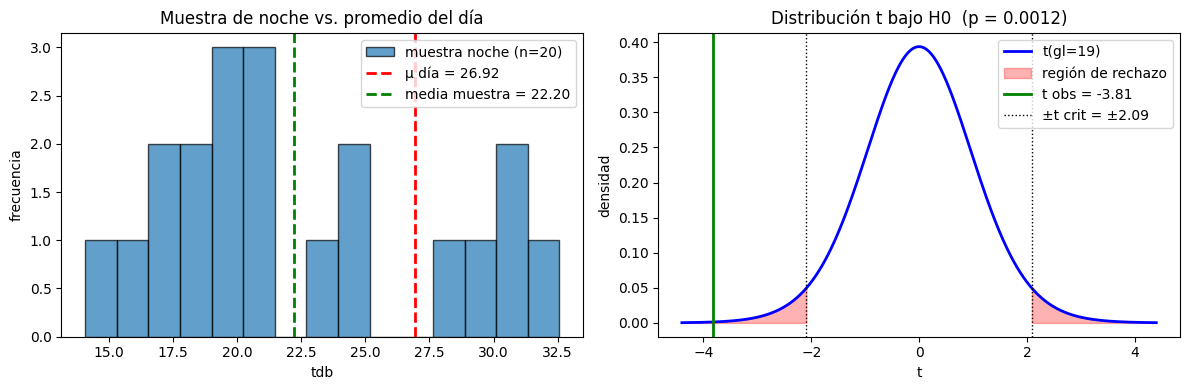

In [135]:
evalua(n=20)

## Puedo comparar un conjunto de datos de la noche, con la noche ?

In [137]:
n = 5
def evalua_noche(n):
    muestra_noche = noche['tdb'].sample(n)
    # H0: la media de la muestra es igual a la media poblacional de noche
    mu_noche = noche['tdb'].mean()
    t_stat, p_valor = stats.ttest_1samp(muestra_noche, popmean=mu_noche)
    
    alpha = 0.05
    print(f'media poblacional noche: {mu_noche:.3f}')
    print(f'media muestra (n={n}): {muestra_noche.mean():.3f}')
    print(f't = {t_stat:.3f},  p = {p_valor:.4f}')
    print('Rechazamos H0 (son distintas)' if p_valor < alpha else 'No rechazamos H0 (estadísticamente iguales)')
    
    gl = n - 1  # grados de libertad
    t_critico = stats.t.ppf(1 - alpha/2, gl)
    
    # eje x para la distribución t bajo H0
    x = np.linspace(-4, 4, 400)
    y = stats.t.pdf(x, gl)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # --- 1) histograma de la muestra vs. media poblacional ---
    ax1.hist(muestra_noche, bins=15, edgecolor='k', alpha=0.7, label=f'muestra (n={n})')
    ax1.axvline(mu_noche, color='red', ls='--', lw=2, label=f'μ noche = {mu_noche:.2f}')
    ax1.axvline(muestra_noche.mean(), color='green', ls='--', lw=2,
              label=f'media muestra = {muestra_noche.mean():.2f}')
    ax1.set_xlabel('tdb'); ax1.set_ylabel('frecuencia')
    ax1.set_title('Muestra vs. media poblacional')
    ax1.legend()
    
    # --- 2) distribución t bajo H0 con regiones de rechazo ---
    ax2.plot(x, y, 'b-', lw=2, label=f't(gl={gl})')
    ax2.fill_between(x, y, where=(x <= -t_critico), color='red', alpha=0.3, label='región de rechazo')
    ax2.fill_between(x, y, where=(x >=  t_critico), color='red', alpha=0.3)
    ax2.axvline(t_stat, color='green', lw=2, label=f't obs = {t_stat:.2f}')
    ax2.axvline( t_critico, color='k', ls=':', lw=1)
    ax2.axvline(-t_critico, color='k', ls=':', lw=1, label=f'±t crit = ±{t_critico:.2f}')
    ax2.set_xlabel('t'); ax2.set_ylabel('densidad')
    ax2.set_title(f'Distribución t bajo H0  (p = {p_valor:.4f})')
    ax2.legend()
    
    plt.tight_layout(); plt.show()

media poblacional noche: 21.922
media muestra (n=500): 21.684
t = -1.407,  p = 0.1600
No rechazamos H0 (estadísticamente iguales)


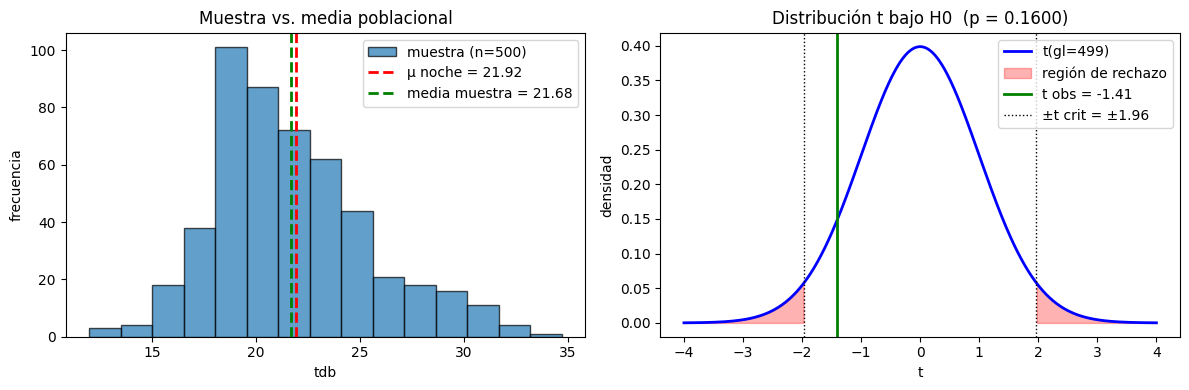

In [163]:
evalua_noche(n=500)

## Qué ejercicios se les ocurre ? 